# Application

This notebook demonstrates `executorlib` in the context of real scientific computing workflows at LANL: **density-functional theory (DFT) calculations** for materials science. Two popular DFT codes are used:

1. **GPAW** — a Python-based DFT code with native `mpi4py` parallelisation
2. **Quantum ESPRESSO** — a Fortran-based DFT code parallelised with its own MPI, invoked as an external executable

In both cases the scientific goal is to compute an **equation-of-state (EOS)** for aluminium: the total energy as a function of unit-cell volume. From the EOS curve the **bulk modulus** (resistance to uniform compression) is extracted by fitting a third-order polynomial and taking the second derivative with respect to volume.

The workflow is the same for both codes:
1. Generate a set of strained crystal structures (volumes ranging ±5% around equilibrium)
2. Submit each structure as a parallel DFT calculation
3. Collect energies and fit the EOS curve
4. Plot the result

**Why `executorlib` is needed here:**
Each DFT calculation internally uses MPI for parallelism. Orchestrating many such calculations simultaneously — a *hierarchical* workflow — is exactly the use case `executorlib` is designed for. The alternative (writing the entire workflow in MPI or managing many `sbatch` scripts by hand) is far more complex.


## GPAW

[GPAW](https://gpaw.readthedocs.io/index.html) is a density-functional theory (DFT) code that implements the projector-augmented wave (PAW) method. It provides a Python interface and uses [mpi4py](https://mpi4py.readthedocs.io) for parallelisation, making it easy to call from Python workflows.

**What is DFT?**
Density-functional theory is the workhorse of computational materials science. It solves a quantum-mechanical approximation to the Schrödinger equation to predict the electronic structure and total energy of a system of atoms. The total energy as a function of atomic configuration is used to compute mechanical properties (bulk modulus, elastic constants), thermodynamic quantities, and more.

**What is the bulk modulus?**
The bulk modulus $B_0$ measures how resistant a material is to uniform compression. It is defined as $B_0 = -V\, dP/dV$, equivalently $B_0 = V\, d^2E/dV^2$ at the equilibrium volume $V_0$. A larger bulk modulus means a stiffer material. For aluminium the experimental value is approximately 76 GPa.

The [atomistics](https://atomistics.readthedocs.io) library provides helper functions to generate the strained structures and fit the EOS. The imports below pull in everything needed for the GPAW workflow:


In [1]:
import subprocess
from ase.build import bulk
from atomistics.workflows import (
    analyse_results_for_energy_volume_curve,
    get_tasks_for_energy_volume_curve,
)
import matplotlib.pyplot as plt
import pprint
from tqdm import tqdm
from time import sleep

/srv/conda/envs/notebook/lib/python3.13/site-packages/atomistics/workflows/__init__.py:77: UserWarning: PhonopyWorkflow(), QuasiHarmonicWorkflow(), get_band_structure(), get_dynamical_matrix(), get_hesse_matrix(), get_thermal_properties_for_harmonic_approximation(), get_tasks_for_harmonic_approximation(), analyse_results_for_harmonic_approximation(), get_tasks_for_quasi_harmonic_approximation(), analyse_results_for_quasi_harmonic_approximation(), get_thermal_properties_for_quasi_harmonic_approximation(), plot_band_structure() and plot_dos() are not available as the import of the module named 'structuretoolkit' failed.
  raise_warning(module_list=phonopy_workflows, import_error=e)


The only function executed in parallel with MPI is `evaluate_with_gpaw()`. All other workflow steps (structure generation, EOS fitting, plotting) run serially in the main Python process. This is the key architectural pattern enabled by `executorlib`: **you write normal, serial Python for the workflow logic and annotate only the compute-intensive functions with parallel resources**.


In [2]:
def evaluate_with_gpaw(task_dict, kpts, encut):
    import os
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["GPAW_MPI4PY"] = "1"

    from mpi4py import MPI
    from gpaw import GPAW, PW
    from gpaw.mpi4pywrapper import MPI4PYWrapper

    structure = task_dict["calc_energy"].copy()
    structure.calc = GPAW(
        xc="PBE",
        mode=PW(encut),
        kpts=kpts,
        communicator=MPI4PYWrapper(MPI.COMM_WORLD),
    )
    return structure.get_potential_energy()

### Generating strained structures

The equilibrium FCC aluminium structure (lattice parameter $a = 4.03$ Å, four atoms per unit cell) is **strained** by expanding and compressing the unit cell volume by up to 5% in `num_points=7` equal steps. This produces seven structures at different volumes, which will each be sent to a separate DFT calculation.

The `get_tasks_for_energy_volume_curve()` function returns a dictionary `task_dict` with a `"calc_energy"` key mapping structure identifiers to ASE `Atoms` objects.


In [3]:
task_dict = get_tasks_for_energy_volume_curve(
    structure=bulk("Al", a=4.03),
    num_points=7,
    vol_range=0.05,
    axes=("x", "y", "z"),
)

The dictionary is reformatted so that each entry has the form `{structure_id: {"calc_energy": atoms_object}}`. This matches the input signature expected by `evaluate_with_gpaw()`, which receives a `task_dict` argument containing the structure to evaluate.


In [4]:
task_loop_dict = {k: {"calc_energy": v} for k, v in task_dict["calc_energy"].items()}

Before submitting calculations it is good practice to confirm that the Flux instance is healthy and that the expected compute resources are available. A missing Flux broker or an allocation with zero free cores will cause submitted jobs to hang indefinitely.


In [5]:
!flux resource list

     STATE NNODES NCORES NGPUS NODELIST
      free      1     16     0 jupyter-janj-lanl-executorlib-tutorial-st9yc3b4
 allocated      0      0     0 
      down      0      0     0 


In [6]:
!flux jobs -a

       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO


### FluxClusterExecutor

The `FluxClusterExecutor` is used here primarily because Flux can be installed on any workstation or test environment without a production HPC cluster. On LANL systems you would typically use the `SlurmClusterExecutor` with an appropriate submission template for the target partition. The API and workflow logic are identical.

The `resource_dict={"cores": 2}` argument tells `executorlib` to allocate 2 MPI tasks to each GPAW calculation. GPAW's internal MPI parallelism will use both cores. Adjust this number based on the system size and available cores.


In [7]:
from executorlib import FluxClusterExecutor

For each strained structure a calculation is submitted to the `FluxClusterExecutor` using `exe.submit()`. The call returns a `Future` immediately; GPAW starts running in the background. All seven calculations are submitted before any result is collected, so they can run concurrently (subject to available cores). After submission, `flux jobs -a` is queried to show the queue state. Finally, `{k: v.result() for k, v in future_dict.items()}` blocks until all futures are resolved and assembles the energy dictionary.


In [8]:
future_dict = {}
with FluxClusterExecutor(pmi_mode="pmix") as exe:
    for k, v in task_loop_dict.items():
        future_dict[k] = exe.submit(
            evaluate_with_gpaw, 
            task_dict=v, 
            kpts=(3, 3, 3), 
            encut=300,
            resource_dict={"cores": 2},
        )
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))
    result_dict = {
        k: f.result()[0]
        for k, f in tqdm(future_dict.items())
    }
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))

['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒ65SSN95 jovyan   executorl+  R      1      1   0.102s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ62F7uuy jovyan   executorl+  R      1      1   0.227s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ5xvPXH9 jovyan   executorl+  R      1      1   0.356s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ5uj5543 jovyan   executorl+  R      1      1   0.482s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ5raibPd jovyan   executorl+  R      1      1   0.605s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ5oPQ9AX jovyan   executorl+  R      1      1   0.730s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ5kGXenT jovyan   executorl+  R      1      1   0.851s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '']


100%|██████████| 7/7 [00:04<00:00,  1.71it/s]


['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒ65SSN95 jovyan   executorl+ CD      1      1   4.926s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ62F7uuy jovyan   executorl+ CD      1      1   4.747s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ5xvPXH9 jovyan   executorl+ CD      1      1   4.669s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ5uj5543 jovyan   executorl+ CD      1      1   4.731s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ5raibPd jovyan   executorl+ CD      1      1   4.572s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ5oPQ9AX jovyan   executorl+ CD      1      1   4.591s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ5kGXenT jovyan   executorl+ CD      1      1   4.506s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '']


### Fitting the equation of state

The seven (volume, energy) pairs are fitted with a third-order Birch–Murnaghan polynomial using `analyse_results_for_energy_volume_curve()`. The fit yields:
- $V_0$: equilibrium volume
- $E_0$: equilibrium energy
- $B_0$: bulk modulus (in GPa)
- $B'_0$: pressure derivative of the bulk modulus

These quantities characterise the mechanical response of the material and are standard benchmarks for DFT codes.


In [9]:
fit_dict = analyse_results_for_energy_volume_curve(
    output_dict={"energy": result_dict},
    task_dict=task_dict,
    fit_type="polynomial",
    fit_order=3,
)

The energy–volume curve plot shows the parabolic relationship between total energy and unit-cell volume. The minimum of the curve corresponds to the equilibrium volume $V_0$. The curvature at the minimum is proportional to the bulk modulus $B_0$, shown in the legend. A steeper parabola (larger $B_0$) indicates a stiffer material.


<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_3044/4024930470.py:2: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Volume [$\AA^3$]")


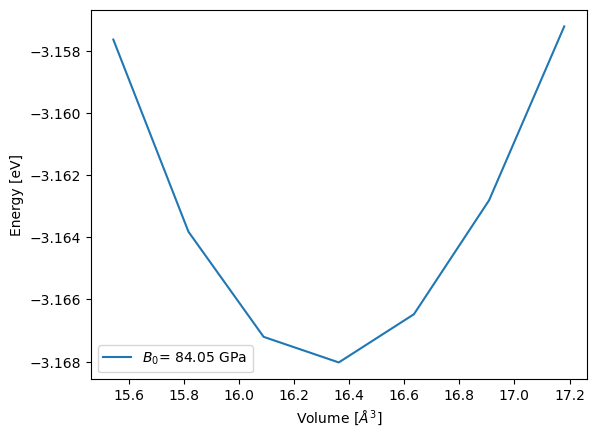

In [10]:
plt.plot(fit_dict["volume"], fit_dict["energy"], label="$B_0$= %0.2f GPa" % fit_dict["bulkmodul_eq"])
plt.xlabel("Volume [$\AA^3$]")
plt.ylabel("Energy [eV]")
plt.legend()

### FluxJobExecutor

The `FluxJobExecutor` runs inside the current Flux allocation (socket-based communication) rather than submitting new Flux jobs from the login node. It is more efficient for this workflow because the GPAW calculations are short enough that the lower per-function overhead of socket communication outweighs the session-independence advantage of `FluxClusterExecutor`.

The workflow logic is identical — only the executor class name changes.


In [11]:
from executorlib import FluxJobExecutor

The submission loop and result collection are the same as with `FluxClusterExecutor`. After all futures resolve, the energy dictionary is assembled and passed to the EOS fitting function.


In [12]:
future_dict = {}
with FluxJobExecutor(pmi_mode="pmix") as exe:
    for k, v in task_loop_dict.items():
        future_dict[k] = exe.submit(
            evaluate_with_gpaw, 
            task_dict=v, 
            kpts=(3, 3, 3), 
            encut=300,
            resource_dict={"cores": 2},
        )
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))
    result_dict = {
        k: f.result()[0]
        for k, f in tqdm(future_dict.items())
    }
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))

['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒFgZzUQw jovyan   python      R      2      1   0.945s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgYWV8b jovyan   python      R      2      1   0.946s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgVYWZu jovyan   python      R      2      1   0.946s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgDEeUA jovyan   python      R      2      1   0.947s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgDEeU9 jovyan   python      R      2      1   0.947s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgDEeU8 jovyan   python      R      2      1   0.947s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgDEeU7 jovyan   python      R      2      1   0.948s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ65SSN95 jovyan   executorl+ CD      1      1   4.926s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ62F7u

100%|██████████| 7/7 [00:02<00:00,  2.51it/s]


['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒFgDEeUA jovyan   python     CD      2      1   3.950s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgYWV8b jovyan   python     CD      2      1   3.945s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgDEeU7 jovyan   python     CD      2      1   3.934s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgDEeU8 jovyan   python     CD      2      1   3.925s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgDEeU9 jovyan   python     CD      2      1   3.917s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgVYWZu jovyan   python     CD      2      1   3.899s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgZzUQw jovyan   python     CD      2      1   3.827s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ65SSN95 jovyan   executorl+ CD      1      1   4.926s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒ62F7u

The EOS fitting and bulk modulus extraction are identical to the `FluxClusterExecutor` case. Comparing the two results (which should agree within numerical noise) validates that both executor backends produce the same scientific output.


In [13]:
fit_dict = analyse_results_for_energy_volume_curve(
    output_dict={"energy": result_dict},
    task_dict=task_dict,
    fit_type="polynomial",
    fit_order=3,
)

The energy–volume curve from the `FluxJobExecutor` calculation should be visually identical to the previous plot. Any small differences in $B_0$ reflect numerical differences in the DFT convergence rather than the choice of executor.


<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_3044/4024930470.py:2: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Volume [$\AA^3$]")


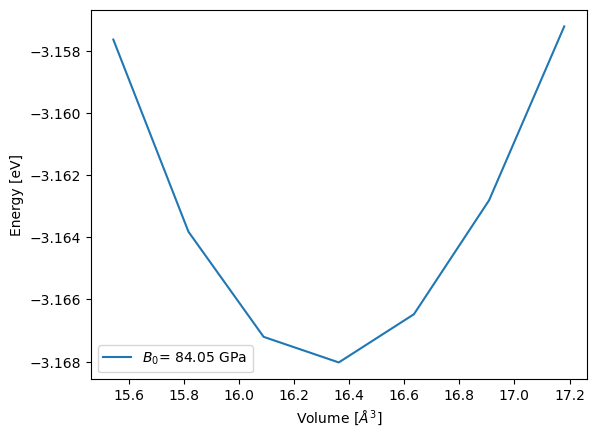

In [14]:
plt.plot(fit_dict["volume"], fit_dict["energy"], label="$B_0$= %0.2f GPa" % fit_dict["bulkmodul_eq"])
plt.xlabel("Volume [$\AA^3$]")
plt.ylabel("Energy [eV]")
plt.legend()

## Quantum ESPRESSO

[Quantum ESPRESSO](https://www.quantum-espresso.org) (QE) is a widely used DFT code written in **Fortran** and parallelised with MPI. Unlike GPAW it does not have a Python API — it is invoked as an external executable (`pw.x`) by reading input files from disk and writing output files to disk.

**Why is this harder to parallelise?**
Because QE has no Python bindings, you cannot simply call it as a function. The standard approach is to write an input file, call `mpirun pw.x < input.in > output.out`, parse the output file, and repeat for each structure. Managing many such invocations by hand requires shell scripting or a workflow manager.

`executorlib` handles this cleanly: the `evaluate_with_quantum_espresso()` function wraps the external call and acts as a *Python adapter* for QE. `executorlib` submits this function in parallel just like any other Python function — it does not matter that internally the function launches a Fortran executable.

> **Important distinction from GPAW:** With GPAW the MPI parallelism is managed by `mpi4py` > inside the Python process. With QE, `executorlib` launches a separate `flux run pw.x` > command for each calculation. This is why `flux_executor_nesting=True` is needed for the > `FluxJobExecutor` case: the function itself needs to spawn a Flux sub-job.


In [15]:
import os
import subprocess
from ase.build import bulk
from atomistics.workflows import (
    analyse_results_for_energy_volume_curve,
    get_tasks_for_energy_volume_curve,
)
import matplotlib.pyplot as plt
import pprint
from tqdm import tqdm
from time import sleep

The `evaluate_with_quantum_espresso()` function constructs the QE input, calls `flux run pw.x` as a subprocess, and parses the output energy. The [ASE](https://wiki.fysik.dtu.dk/ase/) Espresso calculator handles input/output formatting. The key line internally is:

```python
flux run -o pmi=pmix -n {cores} pw.x -in input.pwi > output.pwo
```

Each call to this function runs one QE DFT calculation on `cores` MPI tasks.


In [16]:
def evaluate_with_quantum_espresso(task_dict, pseudopotentials, kpts):
    from ase.calculators.espresso import Espresso, EspressoProfile
    from atomistics.calculators import evaluate_with_ase
    
    return evaluate_with_ase(
        task_dict=task_dict,
        ase_calculator=Espresso(
            pseudopotentials=pseudopotentials,
            tstress=True,
            tprnfor=True,
            kpts=kpts,
            profile=EspressoProfile(
                command="flux run pw.x",
                pseudo_dir="/home/jovyan/espresso/pseudo",
            ),
        ),
    )["energy"]

### Pseudopotentials

DFT calculations require **pseudopotentials** — pre-computed files that describe how each element's core electrons are approximated. Pseudopotentials are element-specific and exchange-correlation-functional-specific. Here the PBE pseudopotential for aluminium (`Al.pbe-n-kjpaw_psl.1.0.0.UPF`) from the [PSLibrary](https://pseudopotentials.quantum-espresso.org) is used. It must be present on disk at the path specified.

The pseudopotential directory is set at `~/espresso/pseudo` (absolute path: `/home/jovyan/espresso/pseudo`).


In [17]:
pseudopotentials = {"Al": "Al.pbe-n-kjpaw_psl.1.0.0.UPF"}

### Generating strained structures

The structure generation for QE follows the same procedure as for GPAW. The only difference is the lattice parameter: for the conventional cubic cell with four atoms the equilibrium parameter is $a = 4.15$ Å (the `cubic=True` flag requests the conventional four-atom cell rather than the primitive two-atom cell used by GPAW).


In [18]:
task_dict = get_tasks_for_energy_volume_curve(
    structure=bulk("Al", a=4.15, cubic=True),
    num_points=7,
    vol_range=0.05,
    axes=("x", "y", "z"),
)

The task dictionary is transformed to the same format as the GPAW case, mapping each structure identifier to a `{"calc_energy": atoms}` dictionary for consumption by `evaluate_with_quantum_espresso()`.


In [19]:
task_loop_dict = {k: {"calc_energy": v} for k, v in task_dict["calc_energy"].items()}

Resource availability is confirmed before submitting QE calculations for the same reasons as in the GPAW section: to verify that the Flux instance is healthy and that cores are available for the parallel calculations.


In [20]:
!flux resource list

     STATE NNODES NCORES NGPUS NODELIST
      free      1     16     0 jupyter-janj-lanl-executorlib-tutorial-st9yc3b4
 allocated      0      0     0 
      down      0      0     0 


In [21]:
!flux jobs -a

       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO
    ƒFgDEeUA jovyan   python     CD      2      1   3.950s jupyter-janj-lanl-executorlib-tutorial-st9yc3b4
    ƒFgYWV8b jovyan   python     CD      2      1   3.945s jupyter-janj-lanl-executorlib-tutorial-st9yc3b4
    ƒFgDEeU7 jovyan   python     CD      2      1   3.934s jupyter-janj-lanl-executorlib-tutorial-st9yc3b4
    ƒFgDEeU8 jovyan   python     CD      2      1   3.925s jupyter-janj-lanl-executorlib-tutorial-st9yc3b4
    ƒFgDEeU9 jovyan   python     CD      2      1   3.917s jupyter-janj-lanl-executorlib-tutorial-st9yc3b4
    ƒFgVYWZu jovyan   python     CD      2      1   3.899s jupyter-janj-lanl-executorlib-tutorial-st9yc3b4
    ƒFgZzUQw jovyan   python     CD      2      1   3.827s jupyter-janj-lanl-executorlib-tutorial-st9yc3b4
    ƒ65SSN95 jovyan   executorl+ CD      1      1   4.926s jupyter-janj-lanl-executorlib-tutorial-st9yc3b4
    ƒ62F7uuy jovyan   executorl+ CD      1      1   4.747s jupyter-janj-lanl-exe

### FluxClusterExecutor

The `FluxClusterExecutor` is used in the same way as for GPAW. Each `evaluate_with_quantum_espresso()` call is submitted as an independent Flux job with `resource_dict={"cores": 2}`, giving each QE calculation two MPI tasks.


In [22]:
from executorlib import FluxClusterExecutor

The submission loop is identical to the GPAW case: submit all calculations first, then collect results. Because QE is an external executable, each function call can take longer than a GPAW call of equivalent size — the file I/O overhead of QE (reading/writing input and output files for each calculation) adds latency compared to the in-memory GPAW interface.


In [23]:
future_dict = {}
with FluxClusterExecutor() as exe:
    for k, v in task_loop_dict.items():
        os.makedirs(os.path.abspath(("strain_%0.2f" % k).replace(".", "_")), exist_ok=True)
        future_dict[k] = exe.submit(
            evaluate_with_quantum_espresso, 
            task_dict=v, 
            pseudopotentials=pseudopotentials, 
            kpts=(3, 3, 3), 
            resource_dict={
                "cores": 1,  # As an external executable is used the number of cores is set to one
                "threads_per_core": 2,  # For external executables the number of threads_per_core specifies the parallel execution
                "cwd": os.path.abspath(("strain_%0.2f" % k).replace(".", "_")),
            },
        )
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))
    result_dict = {
        k: f.result() 
        for k, f in tqdm(future_dict.items())
    }
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))

['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒTv9SjPM jovyan   jovyan      R      1      1   0.141s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTrsgKKD jovyan   jovyan      R      1      1   0.270s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTojKqeo jovyan   jovyan      R      1      1   0.392s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTkcTMGj jovyan   jovyan      R      1      1   0.514s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒThU6scK jovyan   jovyan      R      1      1   0.637s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTeNiNWb jovyan   jovyan      R      1      1   0.759s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTbEMtrB jovyan   jovyan      R      1      1   0.880s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgDEeUA jovyan   python     CD      2      1   3.950s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgYWV

100%|██████████| 7/7 [03:26<00:00, 29.48s/it] 


['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '    ƒTbEMtrB jovyan   jovyan     CD      1      1   3.466m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒThU6scK jovyan   jovyan     CD      1      1   3.005m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTeNiNWb jovyan   jovyan     CD      1      1   2.036m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTojKqeo jovyan   jovyan     CD      1      1   1.833m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTkcTMGj jovyan   jovyan     CD      1      1   1.597m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTrsgKKD jovyan   jovyan     CD      1      1   1.473m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTv9SjPM jovyan   jovyan     CD      1      1   25.62s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgDEeUA jovyan   python     CD      2      1   3.950s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒFgYWV

The EOS fitting uses the same `analyse_results_for_energy_volume_curve()` function as before. The `equilibrium_parameters` call extracts $V_0$ and $E_0$ from the fit to anchor the curve.


In [24]:
fit_dict = analyse_results_for_energy_volume_curve(
    output_dict={"energy": result_dict},
    task_dict=task_dict,
    fit_type="polynomial",
    fit_order=3,
)

The energy–volume curve for aluminium computed with Quantum ESPRESSO. The bulk modulus value should be close to the experimental value of ~76 GPa and to the GPAW result, validating both the calculation setup and the workflow.


<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_3044/4024930470.py:2: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Volume [$\AA^3$]")


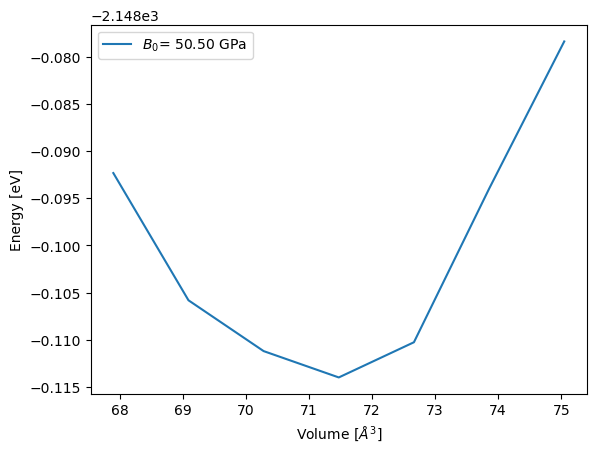

In [25]:
plt.plot(fit_dict["volume"], fit_dict["energy"], label="$B_0$= %0.2f GPa" % fit_dict["bulkmodul_eq"])
plt.xlabel("Volume [$\AA^3$]")
plt.ylabel("Energy [eV]")
plt.legend()

### FluxJobExecutor

The `FluxJobExecutor` requires `flux_executor_nesting=True` for the Quantum ESPRESSO workflow because the `evaluate_with_quantum_espresso()` function **internally calls `flux run pw.x`** — a nested Flux job submission. Flux must be told to allow this nesting explicitly.

This is different from the GPAW case where GPAW's MPI parallelism is managed by `mpi4py` within the Python process and does not require nested Flux jobs.


In [26]:
from executorlib import FluxJobExecutor

The submission loop for `FluxJobExecutor` is identical to the `FluxClusterExecutor` case. The `flux_executor_nesting=True` flag is the only difference in the executor configuration.


In [27]:
future_dict = {}
with FluxJobExecutor(flux_executor_nesting=True) as exe:
    for k, v in task_loop_dict.items():
        os.makedirs(os.path.abspath(("strain_%0.2f" % k).replace(".", "_")), exist_ok=True)
        future_dict[k] = exe.submit(
            evaluate_with_quantum_espresso, 
            task_dict=v, 
            pseudopotentials=pseudopotentials, 
            kpts=(3, 3, 3), 
            resource_dict={
                "cores": 1,  # As an external executable is used the number of cores is set to one
                "threads_per_core": 2,  # For external executables the number of threads_per_core specifies the parallel execution
                "cwd": os.path.abspath(("strain_%0.2f" % k).replace(".", "_")),
            },
        )
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))
    result_dict = {
        k: f.result() 
        for k, f in tqdm(future_dict.items())
    }
    sleep(1)
    pprint.pp(subprocess.check_output(["flux", "jobs", "-a"], universal_newlines=True).split("\n"))

['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '   ƒ34eJsNnT jovyan   flux        R      1      1   0.940s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34eHPPW7 jovyan   flux        R      1      1   0.942s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34eERQwS jovyan   flux        R      1      1   0.956s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34eERQwR jovyan   flux        R      1      1   0.956s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34eCwRf5 jovyan   flux        R      1      1   0.956s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34e9yT6P jovyan   flux        R      1      1   0.956s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34dybY7y jovyan   flux        R      1      1   0.957s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTbEMtrB jovyan   jovyan     CD      1      1   3.466m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒThU6s

100%|██████████| 7/7 [03:23<00:00, 29.10s/it] 


['       JOBID USER     NAME       ST NTASKS NNODES     TIME INFO',
 '   ƒ34e9yT6P jovyan   flux       CD      1      1   3.423m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34eERQwR jovyan   flux       CD      1      1   3.063m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34eCwRf5 jovyan   flux       CD      1      1   2.036m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34eHPPW7 jovyan   flux       CD      1      1    1.83m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34eERQwS jovyan   flux       CD      1      1   1.584m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34dybY7y jovyan   flux       CD      1      1    1.47m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '   ƒ34eJsNnT jovyan   flux       CD      1      1   25.78s '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒTbEMtrB jovyan   jovyan     CD      1      1   3.466m '
 'jupyter-janj-lanl-executorlib-tutorial-st9yc3b4',
 '    ƒThU6s

EOS fitting is identical across all executor types — the scientific result depends only on the energies computed by Quantum ESPRESSO, not on which executor orchestrated the calculations.


In [28]:
fit_dict = analyse_results_for_energy_volume_curve(
    output_dict={"energy": result_dict},
    task_dict=task_dict,
    fit_type="polynomial",
    fit_order=3,
)

The final energy–volume curve from `FluxJobExecutor` with Quantum ESPRESSO. Comparing with the `FluxClusterExecutor` result confirms that both executor backends produce consistent scientific output.


<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_3044/4024930470.py:2: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Volume [$\AA^3$]")


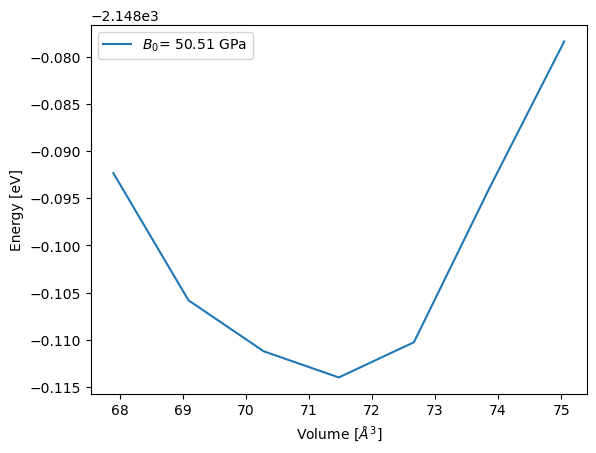

In [29]:
plt.plot(fit_dict["volume"], fit_dict["energy"], label="$B_0$= %0.2f GPa" % fit_dict["bulkmodul_eq"])
plt.xlabel("Volume [$\AA^3$]")
plt.ylabel("Energy [eV]")
plt.legend()